# Solutions · 00 · Python for thermodynamics

Worked solutions to the exercises of [notebook 00](../notebooks/00_python_for_thermodynamics.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import datasets, steam, tables
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

Draw the p-v diagram of water (log axes) with the saturation dome and the isotherms 100, 300, 500 and 700 degC.

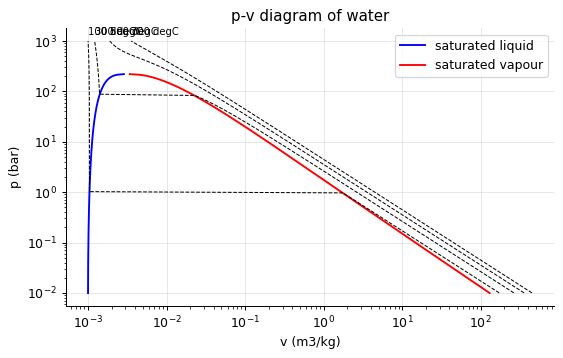

In [2]:
Ts = np.linspace(280, 647, 150)
sats = [steam.saturated(T=T) for T in Ts]
plt.loglog([s["liquid"]["v"] for s in sats], [s["p"] / 1e5 for s in sats], "b", label="saturated liquid")
plt.loglog([s["vapour"]["v"] for s in sats], [s["p"] / 1e5 for s in sats], "r", label="saturated vapour")
for T_C in (100, 300, 500, 700):
    pp = np.logspace(3, np.log10(100e6), 200)
    vv = [steam.state(T=T_C + 273.15, p=p)["v"] if not (T_C + 273.15 <= 647 and abs(p - steam.psat(T_C + 273.15)) < 1) else np.nan for p in pp]
    plt.loglog(vv, pp / 1e5, "k--", lw=0.8); plt.text(vv[-1], pp[-1] / 1e5 * 1.3, f"{T_C} degC", fontsize=8)
plt.xlabel("v (m3/kg)"); plt.ylabel("p (bar)"); plt.title("p-v diagram of water"); plt.legend(); plt.show()

On log axes the dome and the isotherms are all visible over six decades of volume. Isotherms below the
critical temperature cross the dome horizontally (the phase change at constant pressure); the 700 degC
isotherm passes smoothly above it, never condensing however high the pressure.

## Exercise 2

Interpolate the ammonia saturation table by hand at -12 degC (h_f, h_g, p) and compare with `FluidTable`.

In [3]:
sat = pd.read_csv(datasets.path("ammonia_saturation.csv"), comment="#")
T = -12 + 273.15
h_f, h_g = np.interp(T, sat.T_K, sat.h_f), np.interp(T, sat.T_K, sat.h_g)
p = np.exp(np.interp(T, sat.T_K, np.log(sat.p_Pa)))
lib = tables.FluidTable("ammonia").saturated(T=T)
print(f"by hand: h_f = {h_f/1e3:.1f}, h_g = {h_g/1e3:.1f} kJ/kg, p = {p/1e5:.3f} bar")
print(f"library: h_f = {lib['liquid']['h']/1e3:.1f}, h_g = {lib['vapour']['h']/1e3:.1f} kJ/kg, p = {lib['p']/1e5:.3f} bar")

by hand: h_f = 144.9, h_g = 1447.8 kJ/kg, p = 2.677 bar
library: h_f = 144.9, h_g = 1447.8 kJ/kg, p = 2.677 bar


Identical: `FluidTable` does the same linear interpolation in temperature (and in the logarithm of the
pressure) that a table user does by hand. Ammonia's enthalpy of vaporisation is about 1.3 MJ/kg - six times
that of R134a - which is why ammonia plants need so little refrigerant mass.

## Exercise 3

**Implement it yourself:** write `Tsat_from_p(p, table)` that inverts the saturation table by interpolating T against ln p, and compare with `FluidTable.Tsat` for R134a at 2, 5 and 10 bar.

In [4]:
def Tsat_from_p(p, table):
    return float(np.interp(np.log(p), np.log(table.p_Pa), table.T_K))
r134 = pd.read_csv(datasets.path("R134a_saturation.csv"), comment="#")
ft = tables.FluidTable("R134a")
for p_bar in (2, 5, 10):
    print(f"{p_bar:2d} bar: by hand {Tsat_from_p(p_bar * 1e5, r134) - 273.15:.2f} degC, library {ft.Tsat(p_bar * 1e5) - 273.15:.2f} degC")

 2 bar: by hand -10.08 degC, library -10.08 degC
 5 bar: by hand 15.74 degC, library 15.74 degC
10 bar: by hand 39.39 degC, library 39.39 degC


Inverting the table means interpolating temperature against ln p - the same straight line read the other
way. The two agree exactly because the library uses the same rule.